In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
All_Beauty.jsonl.gz

NameError: name 'All_Beauty' is not defined

In [3]:
import os

os.listdir()

['.gitconfig',
 '.config',
 '.pythonstartup.py',
 '.cache',
 '.anaconda',
 '.vimrc',
 'README.ipynb',
 '.profile',
 '.ipython',
 '.jupyter',
 '.bashrc',
 '.ipynb_checkpoints',
 'anaconda_projects',
 '.npm',
 '.local',
 '.conda',
 '.virtualenvs',
 'Amazon_Product_Intelligence.ipynb']

In [8]:
All_Beauty.jsonl.gz

NameError: name 'All_Beauty' is not defined

In [9]:
import os

os.listdir()

['.gitconfig',
 '.config',
 '.pythonstartup.py',
 '.cache',
 '.anaconda',
 '.vimrc',
 'README.ipynb',
 '.profile',
 '.ipython',
 '.jupyter',
 '.bashrc',
 '.ipynb_checkpoints',
 'All_Beauty.jsonl.gz',
 'anaconda_projects',
 '.npm',
 '.local',
 '.conda',
 '.virtualenvs',
 'Amazon_Product_Intelligence.ipynb']

In [10]:
import os

os.getcwd()

'/home/6a11086c-f3b4-44a1-b246-854109fdd525'

In [11]:
import pandas as pd

df = pd.read_json(
    "All_Beauty.jsonl.gz",
    lines=True
)

print(df.shape)

(701528, 10)


In [12]:
df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 701528 entries, 0 to 701527
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             701528 non-null  int64         
 1   title              701528 non-null  object        
 2   text               701528 non-null  object        
 3   images             701528 non-null  object        
 4   asin               701528 non-null  object        
 5   parent_asin        701528 non-null  object        
 6   user_id            701528 non-null  object        
 7   timestamp          701528 non-null  datetime64[ns]
 8   helpful_vote       701528 non-null  int64         
 9   verified_purchase  701528 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(6)
memory usage: 48.8+ MB


'\ Product managers receive thousands of customer reviews and cannot manually monitor product performance. This project develops a data-driven framework that combines KPIs, statistical analysis, and machine learning to identify high-risk products and understand customer satisfaction patterns.

In [14]:
df.head(4)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True


In [15]:
df["review_length"] = df["text"].str.len()

df["review_length"].describe()

count    701528.000000
mean        173.031641
std         246.924645
min           0.000000
25%          44.000000
50%         102.000000
75%         209.000000
max       14989.000000
Name: review_length, dtype: float64

In [17]:
print("Unique Products:",
      df["parent_asin"].nunique())

Unique Products: 112565


In [18]:
def sentiment_class(rating):

    if rating >= 4:
        return "Positive"

    elif rating <= 2:
        return "Negative"

    else:
        return "Neutral"

In [19]:
df["sentiment"] = df["rating"].apply(sentiment_class)

df["sentiment"].value_counts()

Positive    500107
Negative    145114
Neutral      56307
Name: sentiment, dtype: int64

In [20]:
print("Unique Users:",
      df["user_id"].nunique())

Unique Users: 631986


In [21]:
print("Average Rating:",
      round(df["rating"].mean(),2))

Average Rating: 3.96


In [22]:
print("Verified Purchase Rate:",
      round(df["verified_purchase"].mean()*100,2),
      "%")

Verified Purchase Rate: 90.51 %


In [1]:
product_kpis = (
    df.groupby("parent_asin")
      .agg(
          avg_rating=("rating", "mean"),
          review_count=("rating", "count"),
          negative_review_rate=("negative_review", "mean"),
          verified_purchase_rate=("verified_purchase", "mean"),
          avg_helpful_votes=("helpful_vote", "mean"),
          avg_review_length=("review_length", "mean")
      )
      .reset_index()
)

product_kpis.head()

NameError: name 'df' is not defined

In [2]:
%whos

Variable               Type        Data/Info
--------------------------------------------
dataframe_columns      function    <function dataframe_columns at 0x718459601430>
dataframe_hash         function    <function dataframe_hash at 0x718459601550>
dtypes_str             function    <function dtypes_str at 0x7184596014c0>
get_dataframes         function    <function get_dataframes at 0x7184596015e0>
getpass                module      <module 'getpass' from '/<...>ib/python3.9/getpass.py'>
hashlib                module      <module 'hashlib' from '/<...>ib/python3.9/hashlib.py'>
import_pandas_safely   function    <function import_pandas_safely at 0x7184906209d0>
is_data_frame          function    <function is_data_frame at 0x7184882aba60>
json                   module      <module 'json' from '/opt<...>hon3.9/json/__init__.py'>


In [3]:
import pandas as pd

df = pd.read_json(
    "All_Beauty.jsonl.gz",
    lines=True
)

print(df.shape)

(701528, 10)


In [6]:
df["review_length"] = df["text"].str.len()

df["negative_review"] = (
    df["rating"] <= 2
).astype(int)

In [5]:
product_kpis = (
    df.groupby("parent_asin")
      .agg(
          avg_rating=("rating", "mean"),
          review_count=("rating", "count"),
          negative_review_rate=("negative_review", "mean"),
          verified_purchase_rate=("verified_purchase", "mean"),
          avg_helpful_votes=("helpful_vote", "mean"),
          avg_review_length=("review_length", "mean")
      )
      .reset_index()
)

In [7]:
product_kpis.head()

,parent_asin,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length
0,0005946468,5.000000,1,0.0,1.0,0.000000,5.000000
1,0123034892,5.000000,1,0.0,1.0,0.000000,12.000000
2,0124784577,4.333333,3,0.0,1.0,0.333333,61.666667
3,0515059560,4.000000,1,0.0,1.0,1.000000,196.000000
4,0692508988,5.000000,1,0.0,1.0,0.000000,273.000000


In [8]:
product_kpis.shape

(112565, 7)

In [9]:
df.groupby("parent_asin")

In [10]:
product_kpis.head()

,parent_asin,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length
0,0005946468,5.000000,1,0.0,1.0,0.000000,5.000000
1,0123034892,5.000000,1,0.0,1.0,0.000000,12.000000
2,0124784577,4.333333,3,0.0,1.0,0.333333,61.666667
3,0515059560,4.000000,1,0.0,1.0,1.000000,196.000000
4,0692508988,5.000000,1,0.0,1.0,0.000000,273.000000


In [11]:
product_kpis.sort_values(
    "review_count",
    ascending=False
).head(10)

,parent_asin,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length
76871,B085BB7B1M,4.620285,1962,0.062691,0.961774,0.887360,200.504587
111957,B0BM4GX6TT,4.135429,1750,0.153143,0.982286,1.847429,246.941714
48354,B07C533XCW,4.468605,1513,0.100463,0.988103,0.144085,131.444151
109536,B09X9BG4FC,4.496361,1374,0.092431,0.958515,0.427948,114.605531
15003,B00R1TAN7I,4.033528,1372,0.174927,0.927843,0.754373,139.173469
91120,B08L5KN7X4,4.015637,1343,0.224870,0.967982,3.116902,152.148920
22483,B019GBG0IE,3.533886,1328,0.297440,0.980422,1.484940,204.244729
32172,B01M1OFZOG,3.962188,1243,0.207562,0.947707,2.117458,177.530973
112537,B0C9CWKY9G,4.845620,1153,0.022550,0.995663,0.168257,98.578491
18412,B0107QYW14,3.928957,1112,0.178058,0.982914,0.580935,82.772482


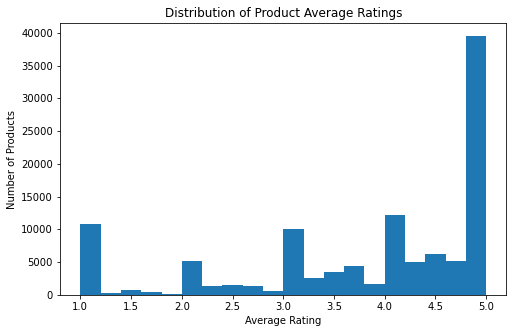

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(product_kpis["avg_rating"], bins=20)
plt.title("Distribution of Product Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Products")
plt.show()

In [13]:
product_kpis["review_count"].describe()

count    112565.000000
mean          6.232204
std          25.189840
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1962.000000
Name: review_count, dtype: float64

In [14]:
reliable_products = product_kpis[
    product_kpis["review_count"] >= 20
]

print(reliable_products.shape)

(6044, 7)


In [15]:
reliable_products.sort_values(
    "avg_rating",
    ascending=False
).head(10)

,parent_asin,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length
26285,B01F0RV4G6,5.0,31,0.0,0.645161,0.838710,243.000000
55196,B07J1QW41Q,5.0,23,0.0,1.000000,0.130435,80.652174
103983,B098F1Z311,5.0,23,0.0,1.000000,0.521739,283.739130
8840,B00FGA6NC8,5.0,29,0.0,0.931034,1.275862,48.896552
85036,B08D34P39V,5.0,20,0.0,1.000000,0.050000,127.800000
81971,B089FQDTPS,5.0,24,0.0,0.875000,0.166667,227.083333
22725,B019X81S82,5.0,22,0.0,1.000000,1.045455,72.863636
26694,B01FPUULM6,5.0,21,0.0,0.952381,0.380952,86.761905
112263,B0BTT658PQ,5.0,27,0.0,1.000000,0.222222,223.333333
69272,B07WRZYZLC,5.0,21,0.0,1.000000,0.476190,100.619048


In [16]:
reliable_products["risk_score"] = (
    (1 - reliable_products["avg_rating"]/5) * 40
    + reliable_products["negative_review_rate"] * 40
    + (1 - reliable_products["verified_purchase_rate"]) * 20
)

/tmp/ipykernel_151/4287418169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable_products["risk_score"] = (


In [17]:
reliable_products.sort_values(
    "risk_score",
    ascending=False
).head(20)

,parent_asin,avg_rating,review_count,negative_review_rate,verified_purchase_rate,avg_helpful_votes,avg_review_length,risk_score
1661,B00170DB4E,2.000000,24,0.708333,0.083333,3.500000,497.708333,70.666667
37386,B0713ZQ6B5,1.200000,20,0.950000,0.950000,1.600000,47.200000,69.400000
107540,B09LD7SQXH,1.185185,54,0.962963,1.000000,0.925926,137.907407,69.037037
58990,B07MP69QK1,1.380952,63,0.920635,0.920635,0.111111,189.920635,67.365079
65524,B07SVBRXHL,1.294118,34,0.911765,1.000000,0.352941,122.588235,66.117647
41394,B074XCKC7X,1.518519,27,0.888889,0.888889,0.148148,233.703704,65.629630
47437,B07BDDBRMJ,1.468085,47,0.914894,0.978723,0.851064,154.234043,65.276596
95070,B08R6BSWSH,1.480000,25,0.920000,1.000000,0.440000,109.480000,64.960000
1639,B00168F4VK,1.535714,28,0.892857,0.928571,5.821429,217.000000,64.857143
61620,B07PSCB3FT,1.428571,21,0.904762,1.000000,0.333333,102.380952,64.761905


In [18]:
reliable_products = product_kpis[
    product_kpis["review_count"] >= 20
].copy()

In [19]:
reliable_products["risk_score"] = (
    (1 - reliable_products["avg_rating"]/5) * 40
    + reliable_products["negative_review_rate"] * 40
    + (1 - reliable_products["verified_purchase_rate"]) * 20
)

In [20]:
print(reliable_products.shape)

(6044, 8)


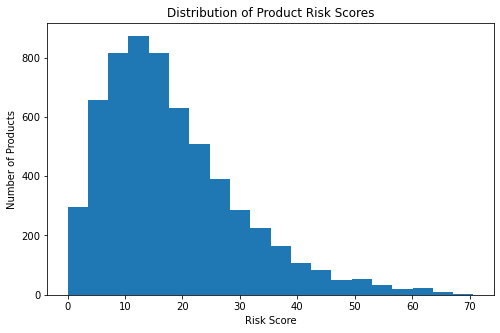

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(reliable_products["risk_score"], bins=20)
plt.title("Distribution of Product Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Products")
plt.show()

In [22]:
reliable_products[
    [
        "avg_rating",
        "negative_review_rate",
        "verified_purchase_rate",
        "review_count"
    ]
].corr()

,avg_rating,negative_review_rate,verified_purchase_rate,review_count
avg_rating,1.000000,-0.976111,-0.063441,0.045792
negative_review_rate,-0.976111,1.000000,0.103463,-0.042276
verified_purchase_rate,-0.063441,0.103463,1.000000,0.030958
review_count,0.045792,-0.042276,0.030958,1.000000


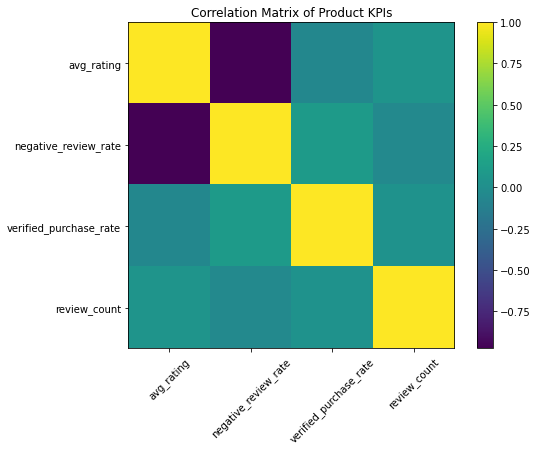

In [23]:
import matplotlib.pyplot as plt

corr_matrix = reliable_products[
    [
        "avg_rating",
        "negative_review_rate",
        "verified_purchase_rate",
        "review_count"
    ]
].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix of Product KPIs")
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

cluster_data = reliable_products[
    [
        "avg_rating",
        "review_count",
        "verified_purchase_rate",
        "avg_helpful_votes",
        "avg_review_length"
    ]
].copy()

cluster_data["review_count"] = np.log1p(cluster_data["review_count"])
cluster_data["avg_helpful_votes"] = np.log1p(cluster_data["avg_helpful_votes"])
cluster_data["avg_review_length"] = np.log1p(cluster_data["avg_review_length"])

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

NameError: name 'np' is not defined

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

reliable_products["cluster"] = kmeans.fit_predict(cluster_scaled)

reliable_products["cluster"].value_counts()

In [ ]:
cluster_profiles = (
    reliable_products
    .groupby("cluster")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("avg_rating", "mean"),
        avg_review_count=("review_count", "mean"),
        avg_negative_rate=("negative_review_rate", "mean"),
        avg_verified_rate=("verified_purchase_rate", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
    .round(3)
)

cluster_profiles

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [26]:
cluster_data = reliable_products[
    [
        "avg_rating",
        "review_count",
        "verified_purchase_rate",
        "avg_helpful_votes",
        "avg_review_length"
    ]
].copy()

cluster_data["review_count"] = np.log1p(cluster_data["review_count"])
cluster_data["avg_helpful_votes"] = np.log1p(cluster_data["avg_helpful_votes"])
cluster_data["avg_review_length"] = np.log1p(cluster_data["avg_review_length"])

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

In [27]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

reliable_products["cluster"] = kmeans.fit_predict(cluster_scaled)

reliable_products["cluster"].value_counts()

3    2789
1    1357
0    1270
2     628
Name: cluster, dtype: int64

In [28]:
cluster_profiles = (
    reliable_products
    .groupby("cluster")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("avg_rating", "mean"),
        avg_review_count=("review_count", "mean"),
        avg_negative_rate=("negative_review_rate", "mean"),
        avg_verified_rate=("verified_purchase_rate", "mean"),
        avg_risk_score=("risk_score", "mean")
    )
    .round(3)
)

cluster_profiles

,products,avg_rating,avg_review_count,avg_negative_rate,avg_verified_rate,avg_risk_score
cluster,,,,,,
0,1270,4.139,153.497,0.162,0.933,14.706
1,1357,3.119,36.252,0.416,0.949,32.724
2,628,4.115,41.946,0.150,0.511,22.867
3,2789,4.296,34.143,0.126,0.953,11.621


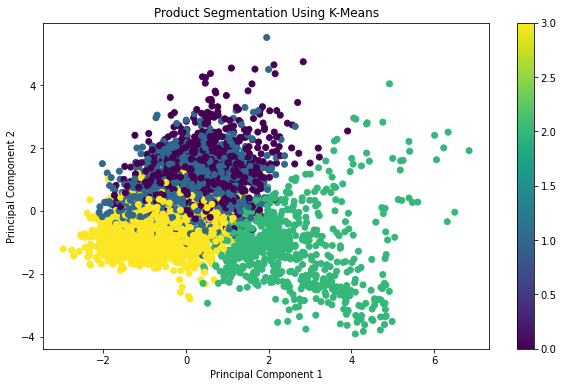

In [29]:
pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(cluster_scaled)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    cluster_pca[:,0],
    cluster_pca[:,1],
    c=reliable_products["cluster"]
)

plt.title("Product Segmentation Using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter)
plt.show()

In [30]:
pca.explained_variance_ratio_

array([0.30985338, 0.23295204])

In [31]:
reliable_products.groupby("cluster")[
    ["avg_rating",
     "negative_review_rate",
     "verified_purchase_rate",
     "risk_score"]
].mean().round(3)

,avg_rating,negative_review_rate,verified_purchase_rate,risk_score
cluster,,,,
0,4.139,0.162,0.933,14.706
1,3.119,0.416,0.949,32.724
2,4.115,0.150,0.511,22.867
3,4.296,0.126,0.953,11.621


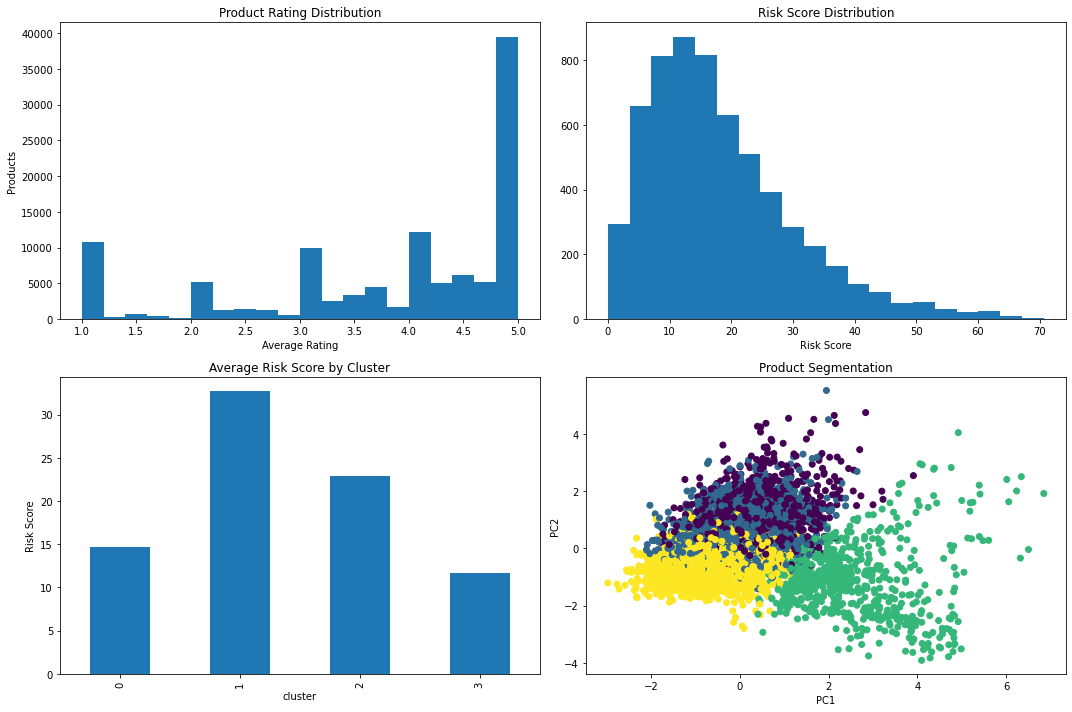

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# 1. Rating Distribution
axes[0,0].hist(product_kpis["avg_rating"], bins=20)
axes[0,0].set_title("Product Rating Distribution")
axes[0,0].set_xlabel("Average Rating")
axes[0,0].set_ylabel("Products")

# 2. Risk Score Distribution
axes[0,1].hist(reliable_products["risk_score"], bins=20)
axes[0,1].set_title("Risk Score Distribution")
axes[0,1].set_xlabel("Risk Score")

# 3. Cluster Risk Comparison
cluster_profiles["avg_risk_score"].plot(
    kind="bar",
    ax=axes[1,0]
)
axes[1,0].set_title("Average Risk Score by Cluster")
axes[1,0].set_ylabel("Risk Score")

# 4. PCA Visualization
scatter = axes[1,1].scatter(
    cluster_pca[:,0],
    cluster_pca[:,1],
    c=reliable_products["cluster"]
)

axes[1,1].set_title("Product Segmentation")
axes[1,1].set_xlabel("PC1")
axes[1,1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [34]:
print("="*50)
print("PRODUCT INTELLIGENCE DASHBOARD")
print("="*50)

print("Products Analyzed:",
      len(product_kpis))

print("Average Product Rating:",
      round(product_kpis["avg_rating"].mean(),2))

print("Average Risk Score:",
      round(reliable_products["risk_score"].mean(),2))

print("Highest Risk Cluster:",
      cluster_profiles["avg_risk_score"].idxmax())

print("Best Performing Cluster:",
      cluster_profiles["avg_rating"].idxmax())

print("="*50)

PRODUCT INTELLIGENCE DASHBOARD
Products Analyzed: 112565
Average Product Rating: 3.82
Average Risk Score: 18.18
Highest Risk Cluster: 1
Best Performing Cluster: 3


In [35]:
cluster_names = {
    0: "Popular Products",
    1: "High-Risk Products",
    2: "Trust Anomaly Products",
    3: "Customer Favorites"
}

reliable_products["cluster_name"] = (
    reliable_products["cluster"]
    .map(cluster_names)
)

reliable_products[
    ["cluster","cluster_name"]
].head()

,cluster,cluster_name
5,0,Popular Products
16,2,Trust Anomaly Products
68,3,Customer Favorites
72,2,Trust Anomaly Products
76,0,Popular Products


In [37]:
ml_data = df[df["rating"] != 3].copy()

ml_data["target"] = (ml_data["rating"] >= 4).astype(int)

ml_data["review_text"] = (
    ml_data["title"].astype(str) + " " + ml_data["text"].astype(str)
)

ml_data = ml_data[
    ml_data["review_text"].str.len() > 10
].copy()

ml_data[["rating", "target", "review_text"]].head()

,rating,target,review_text
0,5,1,Such a lovely scent but not overpowering. This...
1,4,1,Works great but smells a little weird. This pr...
2,5,1,"Yes! Smells good, feels great!"
3,1,0,Synthetic feeling Felt synthetic
5,4,1,Pretty Color The polish was quiet thick and di...


In [39]:
ml_sample = ml_data.sample(
    n=100000,
    random_state=42
)

ml_sample["target"].value_counts(normalize=True)

1    0.77399
0    0.22601
Name: target, dtype: float64

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X = ml_sample["review_text"]
y = ml_sample["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.93505
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      4520
           1       0.94      0.97      0.96     15480

    accuracy                           0.94     20000
   macro avg       0.92      0.89      0.90     20000
weighted avg       0.93      0.94      0.93     20000



In [41]:
confusion_matrix(y_test, y_pred)

array([[ 3614,   906],
       [  393, 15087]])

In [42]:
feature_names = np.array(tfidf.get_feature_names_out())
coefficients = model.coef_[0]

positive_words = feature_names[np.argsort(coefficients)[-20:]]
negative_words = feature_names[np.argsort(coefficients)[:20]]

print("Words associated with positive reviews:")
print(positive_words)

print("\nWords associated with negative reviews:")
print(negative_words)

Words associated with positive reviews:
['excelente' 'fantastic' 'highly' 'easy' 'helps' 'favorite' 'loved'
 'wonderful' 'exactly' 'loves' 'beautiful' 'excellent' 'awesome' 'nice'
 'best' 'amazing' 'works' 'perfect' 'great' 'love']

Words associated with negative reviews:
['disappointed' 'star' 'return' 'terrible' 'horrible' 'poor'
 'disappointing' 'waste' 'broke' 'worst' 'unfortunately' 'returning'
 'awful' 'useless' 'broken' 'didn' 'returned' 'cheap' 'doesn work'
 'don buy']
